# Multi-Dataset Diagnostic Plots
CRC, Lung, Pancreas Multi-Task LoRA performance.


In [19]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

PROJECT = Path('/hpc/group/jilab/tc459/MorphPT')

# === CONFIGURATION ===
# Change this to 'crc', 'lung', 'pancreas', or 'pancreas_top200'
DATASET = 'crc' 

CONFIGS = {
    'crc': {
        'exp_dir': PROJECT / 'experiments' / 'lora_probing_crc_multi_10.0x_mse',
        'cache_dir': PROJECT / 'cache_crc'
    },
    'lung': {
        'exp_dir': PROJECT / 'experiments' / 'lora_probing_lung_multi_10.0x_mse',
        'cache_dir': PROJECT / 'cache_lung'
    },
    'pancreas_top400': {
        'exp_dir': PROJECT / 'experiments' / 'lora_probing_pancreas_top400_multi_10.0x_mse_seed42',
        'cache_dir': PROJECT / 'cache_pancreas'
    },
    #'pancreas_top200': {
    #    'exp_dir': PROJECT / 'experiments' / 'lora_probing_pancreas_top200_multi_10.0x_mse_seed42',
    #    'cache_dir': PROJECT / 'cache_pancreas'
    #}
}

EXP_DIR = CONFIGS[DATASET]['exp_dir']
CACHE_DIR = CONFIGS[DATASET]['cache_dir']

print(f"Analyzing Dataset: {DATASET.upper()}")
print(f"Exp Dir: {EXP_DIR}")
print(f"Cache Dir: {CACHE_DIR}")


Analyzing Dataset: CRC
Exp Dir: /hpc/group/jilab/tc459/MorphPT/experiments/lora_probing_crc_multi_10.0x_mse
Cache Dir: /hpc/group/jilab/tc459/MorphPT/cache_crc


In [20]:
# Load predictions
try:
    y_true = np.load(EXP_DIR / 'test_y_true_seed_42.npy')
    y_pred = np.load(EXP_DIR / 'test_y_pred_seed_42.npy')
    try:
        info = json.loads((EXP_DIR / 'seed_42_info.json').read_text())
        mean_r = info.get("test_r", np.nan)
    except:
        mean_r = np.nan
        
    N, G = y_true.shape
    print(f'Test cells : {N:,}')
    print(f'Num genes  : {G}')
    print(f'Mean r     : {mean_r:.4f}')
except FileNotFoundError:
    print(f"⚠️ Predictions not found in {EXP_DIR}. Did the job finish?")
    df = None


Test cells : 26,659
Num genes  : 400
Mean r     : 0.3218


In [21]:
try:
    # Load Gene Stats & Coverage
    res_path = EXP_DIR / 'multi_lora_hybrid_results.csv'
    if res_path.exists():
        df_res = pd.read_csv(res_path)
        print(f"Loaded {len(df_res)} genes from results CSV.")
    else:
        print(f"⚠️ {res_path} not found.")

    stats_path = CACHE_DIR / 'per_gene/top400_variance_mincov0.1_train_seed42.csv'
   
    if stats_path.exists():
        df_stats = pd.read_csv(stats_path)
    else:
        print(f"⚠️ {stats_path} not found.")
        
    # Merge
    if res_path.exists() and stats_path.exists():
        #df = pd.merge(df_res, df_stats, on='gene_name', how='inner')
        df = pd.merge(df_res, df_stats, on=['gene_idx', 'gene_name'], how='inner')
        print(f"Merged Data Shape: {df.shape}")
    else:
        df = None
except Exception as e:
    print(f"Error loading stats: {e}")
    df = None


Loaded 400 genes from results CSV.
Merged Data Shape: (400, 9)


In [22]:
if df is not None:
    print("📈 ============ Top N 平均 Pearson Correlation (按测试集 R 分数降序) ============")
    df_sorted_by_r = df.sort_values('test_pearson_s42', ascending=False)
    for N in [10, 20, 50, 100, 200, 400]:
        if N <= len(df_sorted_by_r):
            print(f"Top {N:>3d}: mean = {df_sorted_by_r.head(N)['test_pearson_s42'].mean():.4f}")
    
    print("\n🧬 ============ Top N 平均 Pearson Correlation (按原本生物学 Variance 降序) ============")
    # Sort by (train_std)variance of the gene

    df_sorted_by_var = df.sort_values('variance', ascending=False)
        
    for N in [10, 20, 50, 100, 200, 400]:
        if N <= len(df_sorted_by_var):
            print(f"Top {N:>3d}: mean = {df_sorted_by_var.head(N)['test_pearson_s42'].mean():.4f}")

    print("\n🏆 ============ Top 20 表现最好的基因 (By TEST R Score) ============")
    display_cols = ['gene_name', 'test_pearson_s42', 'test_std', 'test_coverage', 'train_nonzero']
    # Select only columns that exist
    display_cols = [c for c in display_cols if c in df.columns]
    print(df_sorted_by_r.head(20)[display_cols].to_string(index=False))


📈 ============ Top N 平均 Pearson Correlation (按测试集 R 分数降序) ============
Top  10: mean = 0.7798
Top  20: mean = 0.7066
Top  50: mean = 0.6040
Top 100: mean = 0.5128
Top 200: mean = 0.4228
Top 400: mean = 0.3218

🧬 ============ Top N 平均 Pearson Correlation (按原本生物学 Variance 降序) ============
Top  10: mean = 0.7628
Top  20: mean = 0.6463
Top  50: mean = 0.5226
Top 100: mean = 0.4406
Top 200: mean = 0.3671
Top 400: mean = 0.3218

🏆 ============ Top 20 表现最好的基因 (By TEST R Score) ============
gene_name  test_pearson_s42
     PIGR          0.942896
      VIM          0.824854
  CEACAM5          0.782501
   COL3A1          0.779926
  CEACAM6          0.769953
    SPARC          0.760716
   COL1A1          0.759438
     IGKC          0.732030
    MUC12          0.729296
   COL1A2          0.716063
    EPCAM          0.680854
     PYGB          0.661727
   IGFBP7          0.655045
     LCN2          0.645368
   LGALS1          0.640946
   COL4A1          0.629099
    PHGR1          0.615598
   COL6A

In [15]:
if df is not None:
    # Prepare standard deviations for Plot 1
    true_std_z = y_true.std(axis=0)
    pred_std_z = y_pred.std(axis=0)
    
    # We must match the order of y_true (which aligns with gene_idx)
    # The merged 'df' might have rows in a different order.
    # Let's map true_std_z and pred_std_z back to df using gene_idx
    
    true_std_map = dict(zip(df_res['gene_idx'], true_std_z))
    pred_std_map = dict(zip(df_res['gene_idx'], pred_std_z))
    
    df['true_std_z'] = df['gene_idx'].map(true_std_map)
    df['pred_std_z'] = df['gene_idx'].map(pred_std_map)
    
    # Coverage for sizes
    min_size = 10
    max_size = 200
    cov = df['coverage']
    sizes = min_size + (cov - cov.min()) / (cov.max() - cov.min()) * (max_size - min_size)


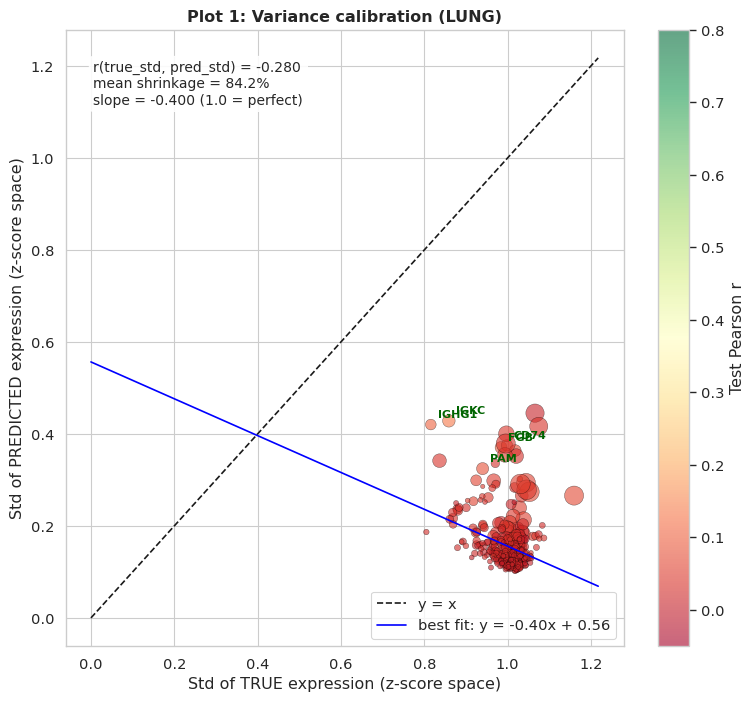

In [16]:
if df is not None:
    fig, ax = plt.subplots(figsize=(9, 8))
    
    sc = ax.scatter(df['true_std_z'], df['pred_std_z'],
                    c=df['test_pearson_s42'], cmap='RdYlGn',
                    vmin=-0.05, vmax=0.8,
                    s=sizes, alpha=0.6,
                    edgecolor='black', lw=0.3, rasterized=True)
    
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Test Pearson r')
    
    lims = [0, max(df['true_std_z'].max(), df['pred_std_z'].max()) * 1.05]
    ax.plot(lims, lims, 'k--', lw=1.2, label='y = x')
    
    # Fit line
    coef = np.polyfit(df['true_std_z'], df['pred_std_z'], 1)
    x_fit = np.array(lims)
    y_fit = coef[0] * x_fit + coef[1]
    ax.plot(x_fit, y_fit, color='blue', lw=1.2, ls='-',
            label=f'best fit: y = {coef[0]:.2f}x + {coef[1]:.2f}')
    
    # Annotate top genes
    top_r = df.nlargest(5, 'test_pearson_s42')
    for _, row in top_r.iterrows():
        ax.annotate(row['gene_name'],
                    xy=(row['true_std_z'], row['pred_std_z']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, fontweight='bold', color='darkgreen')
                    
    r_std_cal, _ = stats.pearsonr(df['true_std_z'], df['pred_std_z'])
    mean_shrink = 1 - (df['pred_std_z'] / df['true_std_z']).mean()
    
    ax.text(0.05, 0.95,
            f'r(true_std, pred_std) = {r_std_cal:.3f}\n'
            f'mean shrinkage = {mean_shrink:.1%}\n'
            f'slope = {coef[0]:.3f} (1.0 = perfect)',
            transform=ax.transAxes, fontsize=10, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
            
    ax.set_xlabel('Std of TRUE expression (z-score space)')
    ax.set_ylabel('Std of PREDICTED expression (z-score space)')
    ax.set_title(f'Plot 1: Variance calibration ({DATASET.upper()})', fontweight='bold')
    ax.legend(loc='lower right')
    plt.show()


In [17]:
if df is not None:
    # Select 6 genes: 2 high r, 2 medium r, 2 low r
    stats_sorted = df.sort_values('test_pearson_s42', ascending=False).reset_index(drop=True)

    high_r = stats_sorted.head(2).copy()
    high_r['tier'] = 'high r'

    n = len(stats_sorted)
    mid_start = n // 2 - 1
    mid_r = stats_sorted.iloc[mid_start:mid_start+2].copy()
    mid_r['tier'] = 'medium r'

    low_r = stats_sorted.tail(2).copy()
    low_r['tier'] = 'low r'

    selected = pd.concat([high_r, mid_r, low_r], ignore_index=True)

    print('Selected 6 genes for spot-level scatter:')
    print(selected[['gene_name', 'coverage', 'true_std_z', 'test_pearson_s42', 'tier']].to_string(index=False))


Selected 6 genes for spot-level scatter:
gene_name  coverage  true_std_z  test_pearson_s42     tier
     IGKC  0.455775    0.858820          0.133850   high r
    IGHG1  0.360107    0.815534          0.103351   high r
   PPP3CB  0.171205    1.030056          0.019652 medium r
    FAM3C  0.186972    1.016693          0.019643 medium r
    ALCAM  0.248228    1.042212         -0.005330    low r
     MDM4  0.207702    1.015602         -0.008201    low r


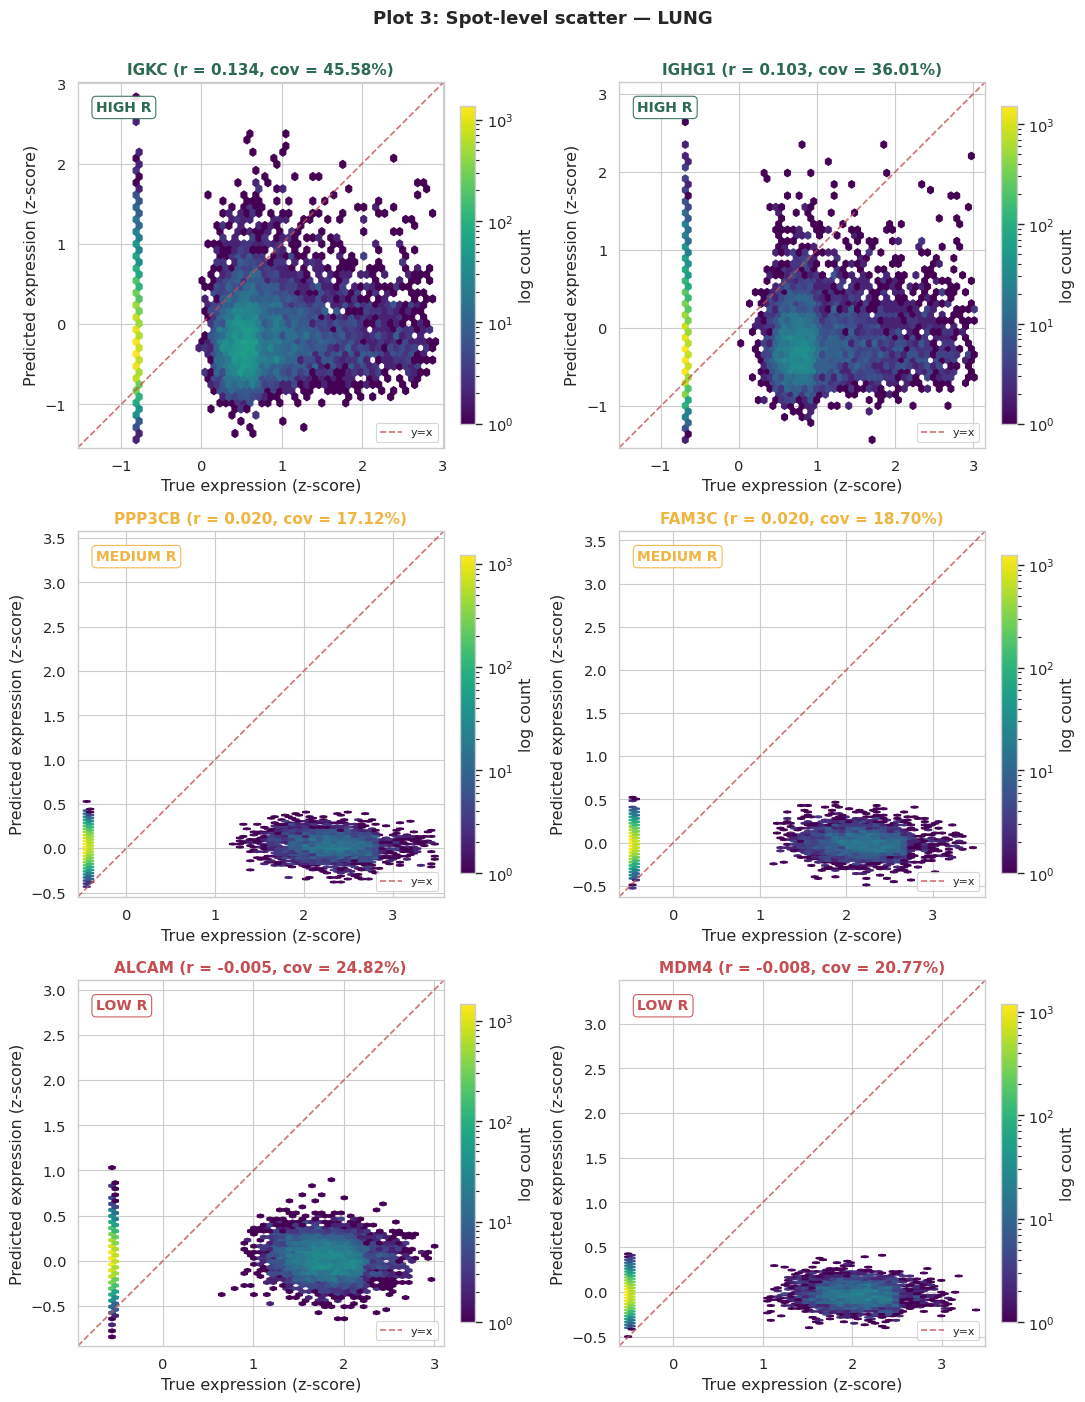

In [18]:
if df is not None:
    fig, axes = plt.subplots(3, 2, figsize=(11, 14))
    tier_colors = {'high r': '#2d6a4f', 'medium r': '#F0B441', 'low r': '#C44E52'}

    idx_to_col = {g: i for i, g in enumerate(df_res['gene_idx'])}


    for i, (_, row) in enumerate(selected.iterrows()):
        ax = axes[i // 2, i % 2]
        idx = int(row['gene_idx'])
        name = row['gene_name']
        r = row['test_pearson_s42']
        tier = row['tier']
        cov = row['coverage']
        
        col_idx = idx_to_col[idx]
        true_vals = y_true[:, col_idx]
        pred_vals = y_pred[:, col_idx]
      

        hb = ax.hexbin(true_vals, pred_vals, gridsize=50,
                       cmap='viridis', bins='log', mincnt=1, rasterized=True)
        plt.colorbar(hb, ax=ax, label='log count', fraction=0.04, pad=0.04)

        lims = [min(true_vals.min(), pred_vals.min()) - 0.1,
                max(true_vals.max(), pred_vals.max()) + 0.1]
        ax.plot(lims, lims, 'r--', lw=1.2, alpha=0.8, label='y=x')

        ax.set_title(f'{name} (r = {r:.3f}, cov = {cov:.2%})',
                     color=tier_colors[tier], fontweight='bold', fontsize=11)
        ax.set_xlabel('True expression (z-score)')
        ax.set_ylabel('Predicted expression (z-score)')

        ax.text(0.05, 0.95, tier.upper(),
                transform=ax.transAxes, fontsize=10, va='top',
                color=tier_colors[tier], fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='white', edgecolor=tier_colors[tier], alpha=0.9))

        ax.legend(loc='lower right', fontsize=8)
        ax.set_xlim(lims)
        ax.set_ylim(lims)

    fig.suptitle(f'Plot 3: Spot-level scatter — {DATASET.upper()}', fontweight='bold', fontsize=13, y=1.0)
    fig.tight_layout()
    plt.show()


## Cross-Dataset Performance Summary
Automatically aggregates the results from all finished datasets in the `CONFIGS` dictionary into a single comparative table.


In [10]:
import glob

summary_data = []

for ds_name, config in CONFIGS.items():
    exp_dir = config['exp_dir']
    res_path = exp_dir / 'multi_lora_hybrid_results.csv'
    
    if res_path.exists():
        df_res = pd.read_csv(res_path)
        
        # 1. 自动寻找对应的 variance / stats 表
        N_genes = len(df_res)
        stat_files = glob.glob(str(config['cache_dir'] / 'per_gene' / f'top{N_genes}_variance*_train_seed42.csv'))
        if stat_files:
            df_stats = pd.read_csv(stat_files[0])
        else:
            fallback_path = config['cache_dir'] / 'per_gene_split_stats_seed_42.csv'
            if fallback_path.exists():
                df_stats = pd.read_csv(fallback_path)
            else:
                print(f"Warning: No stats file found for {ds_name}")
                continue
                
        # 2. 合并表格，把方差引进来
        if 'gene_idx' in df_res.columns and 'gene_idx' in df_stats.columns:
            df = pd.merge(df_res, df_stats, on=['gene_idx', 'gene_name'], how='inner')
        else:
            df = pd. pd.merge(df_res, df_stats, on='gene_name', how='inner')
            
        # 3. 按预测得分 R 排序
        df_r = df.sort_values('test_pearson_s42', ascending=False)
        
        # 4. 按真实的生物学方差排序 (兼容不同列名)
        if 'variance' in df.columns:
            df_var = df.sort_values('variance', ascending=False)
        elif 'train_std' in df.columns:
            df_var = df.sort_values('train_std', ascending=False)
        elif 'test_std' in df.columns:
            df_var = df.sort_values('test_std', ascending=False)
        else:
            df_var = df_r

        record = {
            'Dataset': ds_name.upper(),
            'Total Genes': len(df),
            'Global Mean R': df['test_pearson_s42'].mean(),
            'Top 20 (By R)': df_r.head(20)['test_pearson_s42'].mean(),
            'Top 50 (By R)': df_r.head(50)['test_pearson_s42'].mean(),
            'Top 100 (By R)': df_r.head(100)['test_pearson_s42'].mean(),
            'Top 200 (By R)': df_r.head(200)['test_pearson_s42'].mean(),
            'All (By R)': df_r['test_pearson_s42'].mean(),
            'Top 20 (By Var)': df_var.head(20)['test_pearson_s42'].mean(),
            'Top 50 (By Var)': df_var.head(50)['test_pearson_s42'].mean(),
            'Top 100 (By Var)': df_var.head(100)['test_pearson_s42'].mean(),
            'Top 200 (By Var)': df_var.head(200)['test_pearson_s42'].mean(),
            'All (By Var)': df_var['test_pearson_s42'].mean(),
        }
        summary_data.append(record)

if summary_data:
    df_summary = pd.DataFrame(summary_data)
    df_summary.set_index('Dataset', inplace=True)
    display(df_summary.round(4))
else:
    print("No finished datasets found to summarize.")


,Total Genes,Global Mean R,Top 20 (By R),Top 50 (By R),Top 100 (By R),Top 200 (By R),All (By R),Top 20 (By Var),Top 50 (By Var),Top 100 (By Var),Top 200 (By Var),All (By Var)
Dataset,,,,,,,,,,,,
CRC,400,0.3218,0.7066,0.6040,0.5128,0.4228,0.3218,0.6463,0.5226,0.4406,0.3671,0.3218
LUNG,400,0.0225,0.0671,0.0522,0.0426,0.0335,0.0225,0.0510,0.0391,0.0340,0.0273,0.0225
PANCREAS_TOP400,400,0.1087,0.5987,0.4122,0.2833,0.1854,0.1087,0.2814,0.2025,0.1714,0.1260,0.1087
